# Demo 2: Controlled Pendulum
## Demo 2.7: Hybrid - Unified within SysSimX Framework / Contact

In [26]:
import sys
import time
import numpy as np
from path import Path
from fmpy import read_model_description

repo_root = Path.getcwd().parent.parent
sys.path.insert(0, str(repo_root))

In [27]:
from SysSimX.utilities.update_fmus import get_fmu_paths
demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path(demo_dir_path / 'ControlledPendulum')
fmu_output_dir = Path(demo_dir_path / 'FMUs')
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=False)

All FMUs for package 'ControlledPendulum' already exist. Skipping generation.


In [28]:
from SysSimX.components.fmu_component import FMUComponent

def build_fmus(fmu_dir, fmu_names, fmu_component_links):
    fmus = {}
    for model_name, fmu_name in fmu_component_links.items():
        fmu_path = fmu_dir / f"{fmu_name}.fmu"
        md = read_model_description(fmu_path)
        fmu_model = FMUComponent(model_name, fmu_path)
        fmus[model_name] = fmu_model
    return fmus

fmu_dir   = repo_root / "demos" / "ControlledPendulum" / "FMUs"
fmu_names = ["Reference", "AngleEncoder", "PID_Continuous", "Drive2"]

fmu_component_links = {"ref": "Reference",
                       "sensor_ref": "AngleEncoder",
                       "sensor_state": "AngleEncoder",
                       "pid": "PID_Continuous",
                       "drive": "Drive2",
                       "pendulum": "Pendulum"}

fmu_models = build_fmus(fmu_dir, fmu_names, fmu_component_links)

ref          = fmu_models["ref"]
sensor_ref   = fmu_models["sensor_ref"]
sensor_state = fmu_models["sensor_state"]
pid          = fmu_models["pid"]
drive        = fmu_models["drive"]

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

In [29]:
# Reference Trajectory Parameters
ref._md.description = "Sinusoidal Reference Trajectory"
ref_freq = 1 # Hz
q_mean_deg = 0
q_ampl_deg = 20
ref.parameters['mean'].start = np.deg2rad(q_mean_deg)
ref.parameters['amplitude'].start = np.deg2rad(q_ampl_deg)
ref.parameters['frequency'].start = ref_freq
print(ref)

FMU Name: ref
FMU Path: /home/flo/repos/SystemSimulation/demos/ControlledPendulum/FMUs/Reference.fmu
FMU Description: Sinusoidal Reference Trajectory

| Name      | Type   |    Start | Unit   | Causality   | Variability   |
|-----------|--------|----------|--------|-------------|---------------|
| q_ref     | Real   |          | rad    | output      | continuous    |
| amplitude | Real   | 0.349066 | rad    | parameter   | fixed         |
| frequency | Real   | 1        | Hz     | parameter   | fixed         |
| mean      | Real   | 0        | rad    | parameter   | fixed         |



In [30]:
# Sensor Configuration
nbits = 12
sensor_ref.parameters['q_max'].start = np.deg2rad(q_mean_deg + q_ampl_deg)
sensor_ref.parameters['q_min'].start = np.deg2rad(q_mean_deg - q_ampl_deg)
sensor_ref.parameters['nBits'].start = nbits
sensor_state.parameters['q_max'].start = np.deg2rad(q_mean_deg + q_ampl_deg)
sensor_state.parameters['q_min'].start = np.deg2rad(q_mean_deg - q_ampl_deg)
sensor_state.parameters['nBits'].start = nbits

# PID Controller Configuration
pid.parameters['k'].start = 10
pid.parameters['Ti'].start = 0.5
pid.parameters['Td'].start = 0.25

# Simulation Configuration
t0, tf, h = 0, 1.5, 0.01

In [31]:
from SysSimX.components.opensim_pendulum import OpenSimPendulum
from SysSimX.fem.pendulum import FEMPendulum

# Initial Conditions
q0_deg  = 0
q0      = np.deg2rad(q0_deg)
omega0  = 0
q_wall_deg = 0

# Define FEM model
fem_pendulum  = FEMPendulum()

fem_pendulum.geom_params.use_wall = True
fem_pendulum.geom_params.q_wall_deg = q_wall_deg
fem_pendulum.sim_params.t_start = t0
fem_pendulum.sim_params.tau     = h
fem_pendulum.sim_params.t_end   = tf
fem_pendulum.init_params.angular_position_deg = q0_deg
fem_pendulum.init_params.angular_velocity     = omega0
fem_pendulum.init_params.angular_acceleration = 0
fem_pendulum._create_mesh()

# Get mass and inertia from FEM model
m_pendulum       = fem_pendulum.mass
inertia_pendulum = fem_pendulum.inertia
print(f"Pendulum mass: {m_pendulum:.3f} kg")
print(f"Pendulum inertia: {inertia_pendulum:.3f} kg m²")
L_computed = np.sqrt(inertia_pendulum / m_pendulum)

# Set parameters for FMU model
eqb_pendulum  = fmu_models["pendulum"]
eqb_pendulum.parameters["m"].start = m_pendulum
eqb_pendulum.parameters["L"].start = L_computed
eqb_pendulum.parameters['q0'].start     = np.deg2rad(q0_deg)
eqb_pendulum.parameters['omega0'].start = omega0
print(eqb_pendulum)

# Wall contact angle
os_pendulum   = OpenSimPendulum()
os_pendulum.mass = m_pendulum
os_pendulum.length = L_computed
os_pendulum.q0     = np.deg2rad(q0_deg)
os_pendulum.omega0 = omega0

Pendulum mass: 15.446 kg
Pendulum inertia: 7.000 kg m²
FMU Name: pendulum
FMU Path: /home/flo/repos/SystemSimulation/demos/ControlledPendulum/FMUs/Pendulum.fmu
FMU Description: 

| Name        | Type   |     Start | Unit   | Causality   | Variability   |
|-------------|--------|-----------|--------|-------------|---------------|
| omega_state | Real   |           | rad/s  | output      | continuous    |
| q_state     | Real   |           | rad    | output      | continuous    |
| torque      | Real   |  0        | N.m    | input       | continuous    |
| L           | Real   |  0.673206 | m      | parameter   | fixed         |
| m           | Real   | 15.4458   | kg     | parameter   | fixed         |
| omega0      | Real   |  0        | rad/s  | parameter   | fixed         |
| q0          | Real   |  0        | rad    | parameter   | fixed         |



In [32]:
for component in [ref, sensor_ref, sensor_state, pid, drive, eqb_pendulum, os_pendulum, fem_pendulum]:
    component.initialize(t0)

state_models = {"EQB": eqb_pendulum,
                "OpenSim": os_pendulum,
                "FEM": fem_pendulum}

mode = "FEM"
plant = state_models[mode]

def time_dependent_model_selection(t):
    if t < tf/3:
        return "EQB"
    elif t < 2*tf/3:
        return "FEM"
    else:
        return "OpenSim"

def position_dependent_model_selection(q):
    if q < np.deg2rad(5):
        return "FEM"
    elif q < np.deg2rad(10):
        return "OpenSim"
    else:
        return "EQB"

def sync_models(t, current_model, new_model):
    current_outputs = current_model.get_outputs()
    q_current = current_outputs['q_state']
    omega_current = current_outputs['omega_state']
    new_model.reinitialize(t, q_state=q_current, omega_state=omega_current)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

In [33]:
state_models['FEM'].initialize_scene()

results = {mode: {} for mode in state_models.keys() }
for mode in results.keys():
    results[mode] = {
        "t": [],
        "q_state": [],
        "omega_state": [],
        "torque": []
    }

t = t0
t_vals = []
q_ref_vals = []

while t <= tf:
        # 1) Get reference signal
        ref.step(t, h)
        q_ref = ref.get_outputs()['q_ref']

        # 2) Get plant outputs at current time
        plant_out = plant.get_outputs()
        q_state, omega_state = plant_out['q_state'], plant_out['omega_state']

        # 3) Determine which model to use
        if fem_pendulum.geom_params.use_wall:
            new_mode = position_dependent_model_selection(q_state)
        else:
            new_mode = time_dependent_model_selection(t)
        if new_mode != mode:
             sync_models(t, plant, state_models[new_mode])
             plant = state_models[new_mode]
             mode = new_mode        

        # 4) Feed reference and state to sensor models
        sensor_ref.set_inputs(q=q_ref); 
        sensor_state.set_inputs(q=q_state)
            
        sensor_ref.step(t, h)
        sensor_state.step(t, h)

        U_q_ref = sensor_ref.get_outputs()['U_q']
        U_q_state = sensor_state.get_outputs()['U_q']

        # 5) Feed sensor outputs to PID controller
        pid.set_inputs(ref=U_q_ref, y=U_q_state)
        #pid.set_inputs(ref=q_ref, y=q_state)
        pid.step(t, h)
        u_pid = pid.get_outputs()['u']

        # 6) Drive
        drive.set_inputs(u_control=u_pid, omega=omega_state)
        drive.step(t, h)
        torque = drive.get_outputs()['torque']

        state = (t, q_ref, q_state, omega_state, torque, mode)

        # 6) Apply torque to plant and step
        if isinstance(plant, FEMPendulum):
            plant.set_drive_torque(torque)
            plant.step(t, h, q_ref)
        else:
            plant.set_inputs(torque=torque)
            plant.step(t, h)
            state_models['FEM'].update_scene(state)
            time.sleep(0.1)

        # Log data
        results[mode]['t'].append(t)
        results[mode]['q_state'].append(q_state)
        results[mode]['omega_state'].append(omega_state)
        results[mode]['torque'].append(torque)
        q_ref_vals.append(q_ref)
        t_vals.append(t)
        
        t += h

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

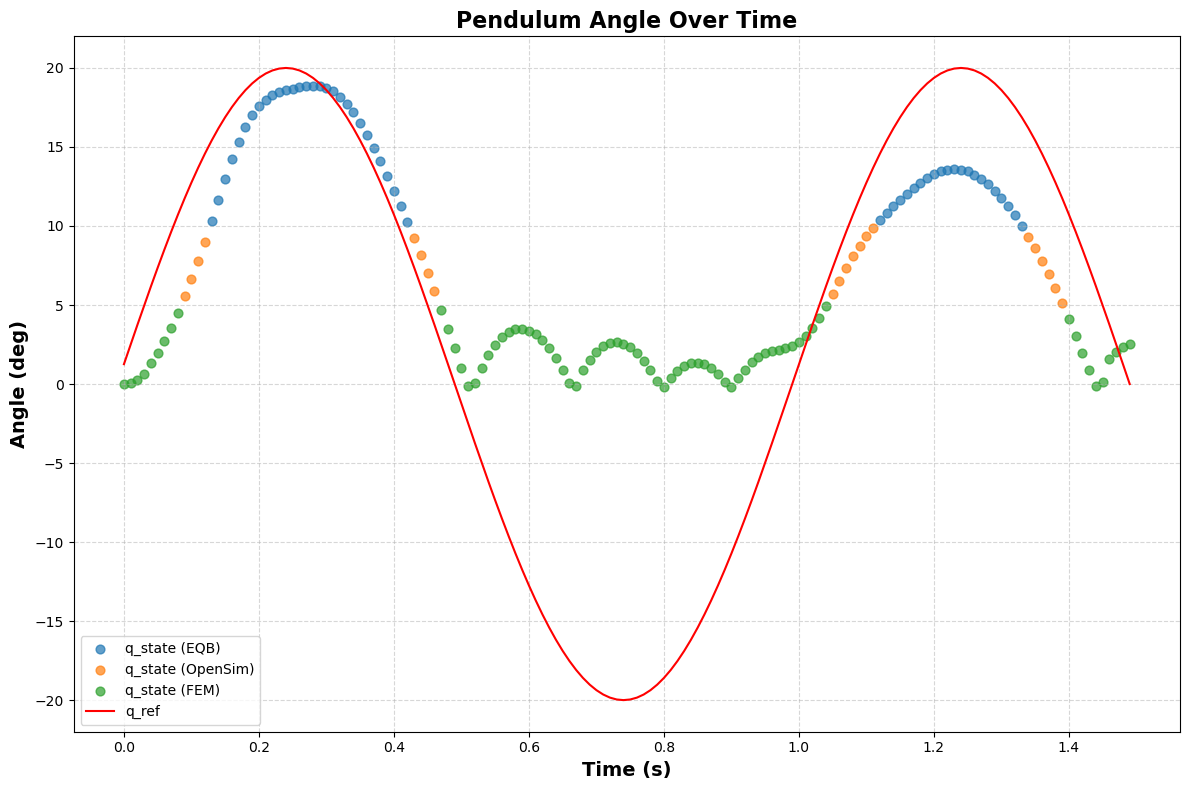

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.title("Pendulum Angle Over Time", fontsize=16, fontweight='bold')

for mode in results.keys():
    res = results[mode]
    ts = res['t']
    q_state_vals = res['q_state']
    plt.scatter(ts, np.rad2deg(q_state_vals), label=f"q_state ({mode})", s=40, alpha=0.7)

plt.plot(t_vals, np.rad2deg(q_ref_vals), label="q_ref", color='red')
plt.xlabel("Time (s)", fontsize=14, fontweight='bold')
plt.ylabel("Angle (deg)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
